#Vectorization

Vectorization is a concept that, along with the broadcasting, is the basis of the internal implementation of NumPy. The vectorization is the absence of explicit loop during the developing of the code. These loops actually cannot be omitted, but are implemented internally and then they are replaced by other constructs in the code. The application of vectorization leads to a more concise and readable code, and you can say that it will appear more “Pythonic” in its appearance. In fact, thanks to the vectorization, many operations take on a more mathematical expression, for example NumPy allows you to express the multiplication of two arrays as shown:

a * b

or even two matrices:

A * B

In [ ]:
# Original concept
a=[1,2,3,4,5,6]
for i in range(len(a)):
  a[i] = a[i] * 2
a

[2, 4, 6, 8, 10, 12]

In [ ]:
#Numpy concept
arr = np.array([1, 2, 3, 4, 5,6])
b=arr*2
b

array([ 2,  4,  6,  8, 10, 12])

In [ ]:
import numpy as np

arr1 = np.array([1, 2, 3, 4, 5])
arr2 = np.array([10, 20, 30, 40, 50])
scalar = 2

print(f"Array 1: {arr1}")
print(f"Array 2: {arr2}")
print(f"Scalar: {scalar}\n")

# Example 1: Element-wise addition of two arrays
result_add = arr1 + arr2
print(f"Element-wise addition (arr1 + arr2): {result_add}\n")

# Example 2: Element-wise multiplication of two arrays
result_multiply = arr1 * arr2
print(f"Element-wise multiplication (arr1 * arr2): {result_multiply}\n")

Array 1: [1 2 3 4 5]
Array 2: [10 20 30 40 50]
Scalar: 2

Element-wise addition (arr1 + arr2): [11 22 33 44 55]

Element-wise multiplication (arr1 * arr2): [ 10  40  90 160 250]



In [ ]:
import numpy as np

arr1 = np.array([1, 2, 3, 4, 5])
scalar = 2

print(f"Array: {arr1}")
print(f"Scalar: {scalar}\n")

# Example 3: Array multiplied by a scalar
result_scalar_mult = arr1 * scalar
print(f"Array multiplied by scalar (arr1 * scalar): {result_scalar_mult}\n")

# Example 4: Array added to a scalar
result_scalar_add = arr1 + scalar
print(f"Array added to scalar (arr1 + scalar): {result_scalar_add}\n")

# Example 5: Using a ufunc (Universal Function) for vectorization
result_sqrt = np.sqrt(arr1)
print(f"Square root of each element (np.sqrt(arr1)): {result_sqrt}")

Array: [1 2 3 4 5]
Scalar: 2

Array multiplied by scalar (arr1 * scalar): [ 2  4  6  8 10]

Array added to scalar (arr1 + scalar): [3 4 5 6 7]

Square root of each element (np.sqrt(arr1)): [1.         1.41421356 1.73205081 2.         2.23606798]


As you can see from these examples, there are no explicit `for` loops. NumPy handles the iteration internally, applying the operations efficiently across all elements of the arrays. This is the essence of vectorization.

#Broadcasting

Broadcasting is the operation that allows an operator or a function to act on two or more arrays to operate even if these arrays do not have exactly the same shape. Actually, not all the dimensions are compatible with each other in order to be subjected to broadcasting but they must meet certain rules.

You saw that using NumPy, you can classify multidimensional arrays through the shape that is a tuple representing the length of the elements for each dimension.

Thus, two arrays may be subjected to broadcasting when all their dimensions are compatible, i.e., the length of each dimension must be equal between the two arrays or one of them must be equal to 1. If these two conditions are not met, you get an exception given that the two arrays are not compatible.

In [ ]:
A = np.arange(16).reshape(4, 4)
b = np.arange(4)


In [ ]:
A

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

In [ ]:
b

array([0, 1, 2, 3])

In this case, you obtain two arrays:

4 x 4

4

The rules of broadcasting are two. The first rule is to add a 1 to each missing dimension. If the compatibility rules are now satisfied you can apply the broadcasting and move to the second rule.

4 x 4

4 x 1

The rule of compatibility is met. Then you can move on to the second rule of broadcasting. This rule explains how to extend the size of the smallest array so that it takes on the same size of the biggest, so that then the element-wise function or operator is applicable.

The second rule assumes that the missing elements (size, length 1) are filled with replicas of the values contained in extended sizes

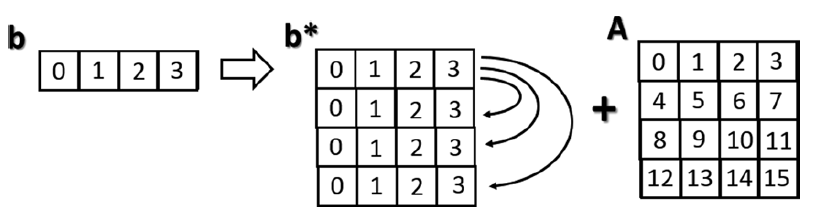

In [ ]:
A+b

array([[ 0,  2,  4,  6],
       [ 4,  6,  8, 10],
       [ 8, 10, 12, 14],
       [12, 14, 16, 18]])

In this case you are in a simple case in which one of the two arrays is smaller than the other. There may be more complex cases in which the two arrays have different shapes but each of them is smaller than the other only for some dimensions.

In [ ]:
m = np.arange(6).reshape(3, 1, 2)
n = np.arange(6).reshape(3, 2, 1)

In [ ]:
m

array([[[0, 1]],

       [[2, 3]],

       [[4, 5]]])

A NumPy array with the shape (3, 1, 2) is a three-dimensional array (3D), where the elements of the tuple describe the length of each corresponding dimension.

The shape (3, 1, 2) can be interpreted as:
3 in the first dimension (axis 0) means there are three "blocks" or "layers" of data.

1 in the second dimension (axis 1) means each block has one "row".

2 in the third dimension (axis 2) means each row has two "columns" or elements.

The total number of elements in the array is the product of the shape elements:
6 elements in total.

In [ ]:
n

array([[[0],
        [1]],

       [[2],
        [3]],

       [[4],
        [5]]])

A NumPy array with the shape (3, 2, 1) is a three-dimensional array (3D array) with a total of elements.

The shape tuple (3, 2, 1) describes the lengths of the array along each of its three axes (dimensions):

Axis 0 (the first dimension) has a length of 3: This indicates the array is composed of three "blocks" or "layers" of data.

Axis 1 (the second dimension) has a length of 2: Each of the three blocks contains two rows.

Axis 2 (the third dimension) has a length of 1: Each row contains one element. This innermost dimension of size 1 means that each element in the 2x1 structure is itself an array of a single value.

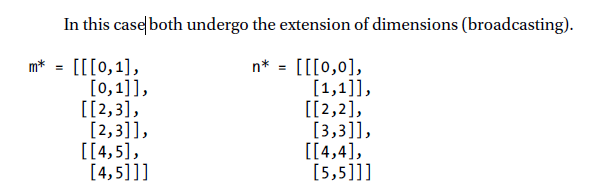

In [ ]:
#And then you can apply, for example, the addition operator between the two arrays, operating element-wise.
m + n

array([[[ 0,  1],
        [ 1,  2]],

       [[ 4,  5],
        [ 5,  6]],

       [[ 8,  9],
        [ 9, 10]]])

#### 1. Scalar-Array Operations (Implicit Broadcasting)

This is the simplest form of broadcasting, where a scalar value is effectively stretched or "broadcast" to match the shape of the array during the operation.

In [ ]:
import numpy as np

arr = np.array([1, 2, 3, 4, 5])
scalar = 10

print(f"Original Array: {arr}")
print(f"Scalar: {scalar}\n")

# Adding a scalar to an array
result_add = arr + scalar
print(f"Array + Scalar: {result_add}\n")

# Multiplying an array by a scalar
result_mul = arr * scalar
print(f"Array * Scalar: {result_mul}")

Original Array: [1 2 3 4 5]
Scalar: 10

Array + Scalar: [11 12 13 14 15]

Array * Scalar: [10 20 30 40 50]


#### 2. 1D Array with 2D Array

Broadcasting can be used to add a 1D array to each row or column of a 2D array. The dimensions must align or one must be 1. For example, to add a 1D array to each row of a 2D array, the 1D array's length must match the number of columns in the 2D array.

In [ ]:
import numpy as np

matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])

row_to_add = np.array([10, 20, 30]) # Shape (3,)

print(f"Original Matrix:\n{matrix}\n")
print(f"Row to Add: {row_to_add}\n")

# Add row_to_add to each row of the matrix
result = matrix + row_to_add
print(f"Matrix + Row_to_Add (broadcasted across rows):\n{result}")

# To add to columns, you might need to reshape the 1D array or use newaxis
# e.g., column_to_add = np.array([[10], [20], [30]]) # Shape (3, 1)
# Or using newaxis: column_to_add_newaxis = np.array([10, 20, 30])[:, np.newaxis] # Shape (3, 1)


Original Matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Row to Add: [10 20 30]

Matrix + Row_to_Add (broadcasted across rows):
[[11 22 33]
 [14 25 36]
 [17 28 39]]


#### 3. Broadcasting with `np.newaxis`

`np.newaxis` is used to increase the dimension of an existing array by one more dimension, which can be useful for making arrays compatible for broadcasting when their shapes don't align perfectly. This adds a singleton dimension (a dimension of size 1).

In [ ]:
import numpy as np

matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]]) # Shape (3, 3)

column_vector = np.array([10, 20, 30]) # Shape (3,)

print(f"Original Matrix:\n{matrix}\n")
print(f"1D Array (column_vector): {column_vector}\n")

# To add column_vector to each column of the matrix, we need to make it a column vector (3, 1)
# Using np.newaxis to convert (3,) to (3, 1)
column_vector_reshaped = column_vector[:, np.newaxis]
print(f"Reshaped 1D Array (column_vector[:, np.newaxis]):\n{column_vector_reshaped}\n")

# Now, add the reshaped 1D array to the matrix
result = matrix + column_vector_reshaped
print(f"Matrix + Reshaped 1D Array (broadcasted across columns):\n{result}")

Original Matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

1D Array (column_vector): [10 20 30]

Reshaped 1D Array (column_vector[:, np.newaxis]):
[[10]
 [20]
 [30]]

Matrix + Reshaped 1D Array (broadcasted across columns):
[[11 12 13]
 [24 25 26]
 [37 38 39]]


#### 4. When Broadcasting Fails

Broadcasting rules are strict. If the dimensions do not match according to the rules, NumPy will raise a `ValueError`.

In [ ]:
import numpy as np

matrix = np.array([[1, 2, 3],
                   [4, 5, 6]]) # Shape (2, 3)

incompatible_array = np.array([10, 20]) # Shape (2,)

print(f"Matrix Shape: {matrix.shape}")
print(f"Incompatible Array Shape: {incompatible_array.shape}\n")

try:
    # This will fail because the trailing dimensions (3 and 2) are not equal and neither is 1
    result = matrix + incompatible_array
    print(result)
except ValueError as e:
    print(f"Broadcasting Error: {e}")

Matrix Shape: (2, 3)
Incompatible Array Shape: (2,)

Broadcasting Error: operands could not be broadcast together with shapes (2,3) (2,) 


#Structured Arrays

So far in the various examples in previous sections, you saw monodimensional and two-dimensional arrays. Actually, NumPy provides the possibility of creating arrays that are much more complex not only in size, but in the structure itself, called precisely structured arrays. This type of array contains structs or records instead of the individual items.

For example, you can create a simple array of structs as items. Thanks to the dtype option, you can specify a list of comma-separated specifiers to indicate the elements that will constitute the struct, along with its data type and order.

bytes b1

int i1, i2, i4, i8

unsigned ints u1, u2, u4, u8

floats f2, f4, f8

complex c8, c16

fixed length strings a<n>

For example, if you want to specify a struct consisting of an integer, a character string of length 6 and a Boolean value, you will specify the three types of data in the dtype option with the right order using the corresponding specifiers.

In [ ]:
structured = np.array([(1, 'First', 0.5, 1+2j),(2, 'Second', 1.3, 2-2j), (3, 'Third', 0.8, 1+3j)],dtype=('i2, a6, f4, c8'))

/tmp/ipykernel_173/2740899938.py:1: DeprecationWarning: Data type alias 'a' was deprecated in NumPy 2.0. Use the 'S' alias instead.
  structured = np.array([(1, 'First', 0.5, 1+2j),(2, 'Second', 1.3, 2-2j), (3, 'Third', 0.8, 1+3j)],dtype=('i2, a6, f4, c8'))


In [ ]:
structured

array([(1, b'First', 0.5, 1.+2.j), (2, b'Second', 1.3, 2.-2.j),
       (3, b'Third', 0.8, 1.+3.j)],
      dtype=[('f0', '<i2'), ('f1', 'S6'), ('f2', '<f4'), ('f3', '<c8')])

In [ ]:
#You may also use the data type explicitly specifying int8, uint8, float16, complex64, and so forth.
structured1= np.array([(1, 'First', 0.5, 1+2j),(2, 'Second', 1.3,2-2j), (3, 'Third', 0.8, 1+3j)],dtype=('int16, a6, float32, complex64'))

/tmp/ipykernel_173/2995282331.py:2: DeprecationWarning: Data type alias 'a' was deprecated in NumPy 2.0. Use the 'S' alias instead.
  structured1= np.array([(1, 'First', 0.5, 1+2j),(2, 'Second', 1.3,2-2j), (3, 'Third', 0.8, 1+3j)],dtype=('int16, a6, float32, complex64'))


In [ ]:
structured1

array([(1, b'First', 0.5, 1.+2.j), (2, b'Second', 1.3, 2.-2.j),
       (3, b'Third', 0.8, 1.+3.j)],
      dtype=[('f0', '<i2'), ('f1', 'S6'), ('f2', '<f4'), ('f3', '<c8')])

However, both cases have the same result. Inside the array you see a dtype sequence containing the name of each item of the struct with the corresponding type of data.

In [ ]:
#Writing the appropriate reference index, you obtain the corresponding row which contains the struct.
structured1[1]

np.void((2, b'Second', 1.3, 2.-2.j), dtype=[('f0', '<i2'), ('f1', 'S6'), ('f2', '<f4'), ('f3', '<c8')])

In [ ]:
#The names that are assigned automatically to each item of struct can be considered as the names of the columns of the array, and then using them as a structured index, you can refer to all the elements of the same type, or of the same ‘column’.
structured1['f1']

array([b'First', b'Second', b'Third'], dtype='|S6')

As you have just seen, the names are assigned automatically with an f (which stands for field) and a progressive integer that indicates the position in the sequence. In fact, it would be more useful to specify the names with something more meaningful. This is possible and you can do it at the time of the declaration of the array:

In [ ]:
structured2= np.array([(1,'First',0.5,1+2j),(2,'Second',1.3,2-2j),(3,'Third',0.8,1+3j)], dtype=[('id','i2'),('position','a6'),('value','f4'),('complex','c8')])

/tmp/ipykernel_173/1839132304.py:1: DeprecationWarning: Data type alias 'a' was deprecated in NumPy 2.0. Use the 'S' alias instead.
  structured2= np.array([(1,'First',0.5,1+2j),(2,'Second',1.3,2-2j),(3,'Third',0.8,1+3j)], dtype=[('id','i2'),('position','a6'),('value','f4'),('complex','c8')])


In [ ]:
structured2

array([(1, b'First', 0.5, 1.+2.j), (2, b'Second', 1.3, 2.-2.j),
       (3, b'Third', 0.8, 1.+3.j)],
      dtype=[('id', '<i2'), ('position', 'S6'), ('value', '<f4'), ('complex', '<c8')])

In [ ]:
structured2.dtype.names = ('id','order','value','complex')

In [ ]:
structured2['order']

array([b'First', b'Second', b'Third'], dtype='|S6')

#Reading and Writing Array Data on Files

A very important aspect of NumPy that has not been taken into account yet is the reading of the data contained within a file. This procedure is very useful, especially when you have to deal with large amounts of data collected within arrays. This is a very common operation in data analysis, since the size of the dataset to be analyzed is almost always huge, and therefore it is not advisable or even possible to manage the transcription and subsequent reading of data by a computer to another manually, or from one session of the calculation to another.

Indeed NumPy provides in this regard a set of functions that allow the data analyst to save the results of his calculations in a text or binary file. Similarly, NumPy allows reading and conversion of written data within a file into an array.

#Loading and Saving Data in Binary Files

Regarding for saving and then later retrieving data stored in binary format, NumPy provides a pair of functions called save() and load().

In [ ]:
#Once you have an array to save, for example, containing the results of your processing during data analysis, you simply call the save() function, specifying as arguments the name of the file, to which .npy extension will be automatically added, and then the array itself.
data=np.random.random((3,3))
data

array([[0.82380579, 0.30162939, 0.14994459],
       [0.66241233, 0.75693819, 0.9553589 ],
       [0.2148253 , 0.65513936, 0.52432478]])

In [ ]:
np.save('saved_data',data)

In [ ]:
#But when you need to recover the data stored within a .npy file, you can use the load() function by specifying the file name as argument, this time adding the extension .npy.
loaded_data = np.load('saved_data.npy')
loaded_data

array([[0.82380579, 0.30162939, 0.14994459],
       [0.66241233, 0.75693819, 0.9553589 ],
       [0.2148253 , 0.65513936, 0.52432478]])

In [ ]:
data = np.genfromtxt('data.csv', delimiter=',', names=True)

In [ ]:
data

array([(1., 123., 1.4, 23.), (2., 110., 0.5, 18.), (3., 164., 2.1, 19.)],
      dtype=[('id', '<f8'), ('value1', '<f8'), ('value2', '<f8'), ('value3', '<f8')])